Step 1: Read and draw a graph
- take a given file in edge list format, e.g. Les Misérables network, Jazz network
- load the file into your own program (build data structures for that)
- create and draw a layout (node-link diagram) for the loaded graph. Feel free to imagine any kind of layout you want, e.g. some user-defined functions for the x,y coordinates.
- explain what's the computational complexity of your layout algorithm
- comment on the pro's / con's of your resulting layout
- (bonus) Give yourself 10 minutes to think of a simple algorithm for graph drawing that theoretically should produce results better than your previous attempt. Implement this algorithm, show your results, compare to the drawings produced by the previous algorithm, and analyze the algorithm’s running time.

## Solution:

### setup

First, let's load the necessary libreries

In [3]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot

Now, we can load the graph data (dot file) using pydot:

In [4]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot"
data_name_2 = "../Dataset/Step1/LesMiserables.dot"
data_name_3 = "../Dataset/OTHERS/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/OTHERS/g.20.27.dot"
data_name_5 = "../Dataset/OTHERS/g.42.88.dot"
data_name_6 = "../Dataset/OTHERS/GD97.dot"
data_name_7 = "../Dataset/OTHERS/LeagueNetwork.dot"
data_name_8 = "../Dataset/OTHERS/mesh graph.dot"
data_name_9 = "../Dataset/OTHERS/noname.dot"
data_name_10 = "../Dataset/OTHERS/polblogs.dot"
data_name_11 = "../Dataset/OTHERS/robot graph.dot"
data_name_12 = "../Dataset/OTHERS/rome.dot"
data_name_13 = "../Dataset/OTHERS/rome.dot"
data_name_14 = "../Dataset/OTHERS/snail graph.dot"

#read in the data from the dot file:
G = pydot.graph_from_dot_file(data_name_1)
graph = G[0]

#extract the nodes and edges from the graph:
nodes = graph.get_nodes()
node_names = [node.get_name() for node in nodes]
edges = graph.get_edges()
edge_list = [(edge.get_source(), edge.get_destination()) for edge in edges]

### taking a look at the graph structure

In [5]:
# create a dataframe with nodes, edges and # of connections
data = [{'nodes': node.get_name(), 
         'connected_edges': [edge.get_destination() for edge in edges if edge.get_source() == node.get_name()],
         'number_of_connections': sum(1 for edge in edges if edge.get_source() == node.get_name())} 
        for node in nodes]
df = pd.DataFrame(data)
df = df.sort_values(by='number_of_connections', ascending=False).reset_index(drop=True) #sorting by # of connections
# visualize the data
df

,nodes,connected_edges,number_of_connections
0,7,"[100, 101, 102, 103, 104, 105, 106, 107, 108, ...",79
1,67,"[28, 32, 33, 35, 38, 41, 42, 48, 52, 53, 55, 5...",78
2,20,"[3, 4, 6, 7, 100, 101, 102, 106, 107, 109, 111...",65
3,23,"[3, 4, 6, 7, 8, 9, 101, 102, 107, 109, 112, 11...",61
4,13,"[2, 3, 4, 6, 7, 9, 101, 111, 112, 114, 121, 12...",56
...,...,...,...
193,99,[],0
194,25,[],0
195,158,[],0
196,186,[],0


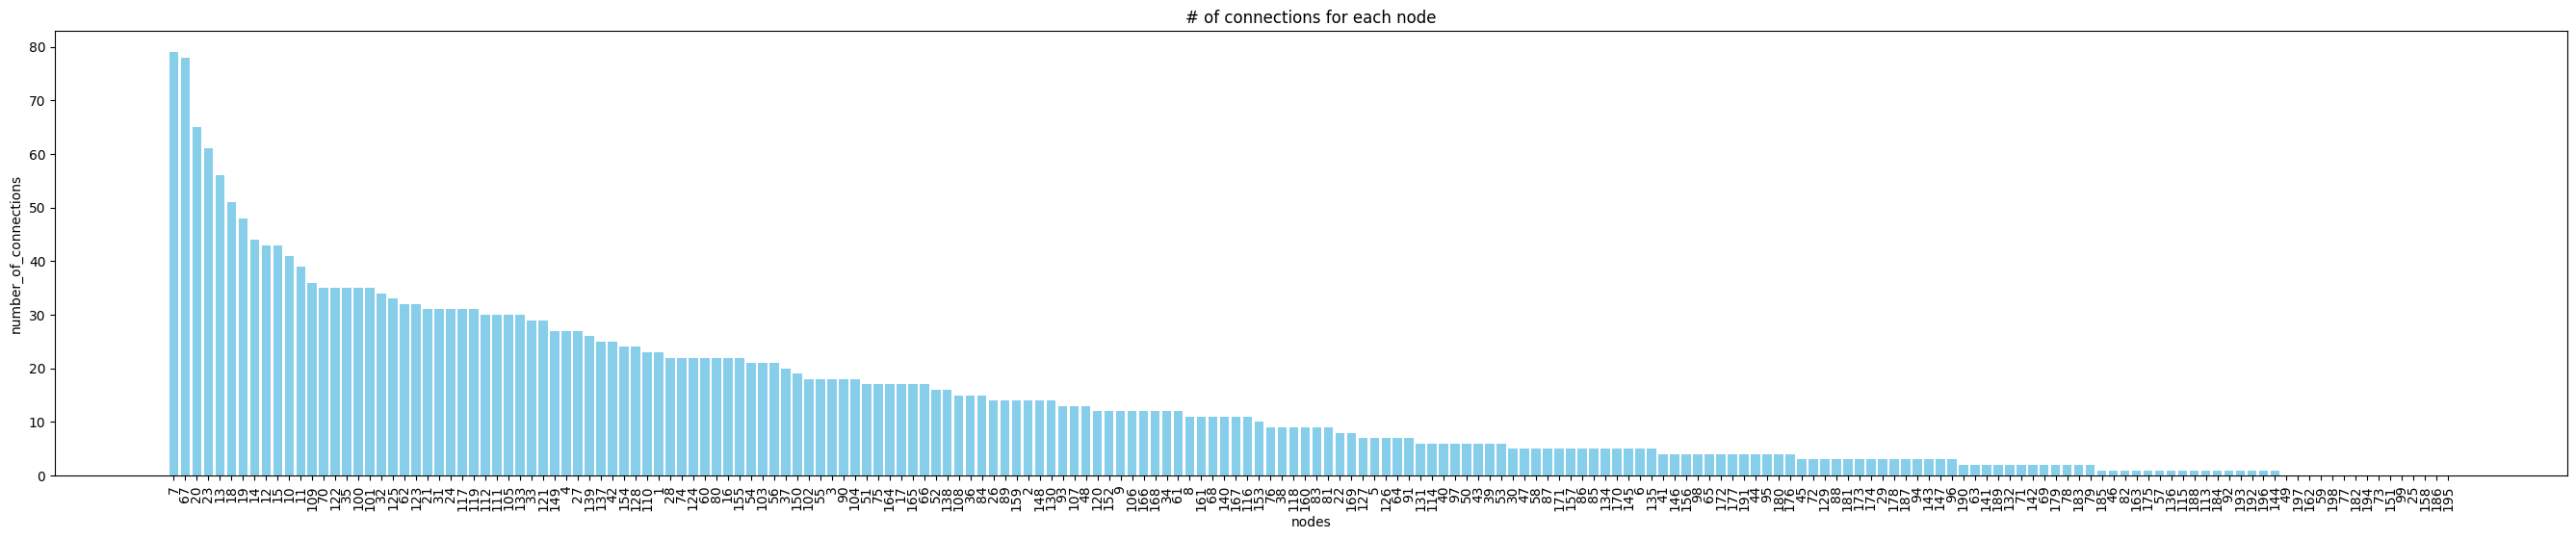

In [6]:
nodes = df['nodes']
n_connections = df['number_of_connections']

# Plot the number of connections for each node
width_of_the_graph = len(nodes) * 0.17
plt.figure(figsize=(width_of_the_graph, 6))
plt.bar(nodes, n_connections, color='skyblue')
plt.xlabel('nodes')
plt.ylabel('number_of_connections')
plt.title('# of connections for each node')
plt.xticks(rotation=90)
plt.show()

### graph layouts

We've developed different versions of the graph layout.

However, we may start with the networkx layout as a reference:

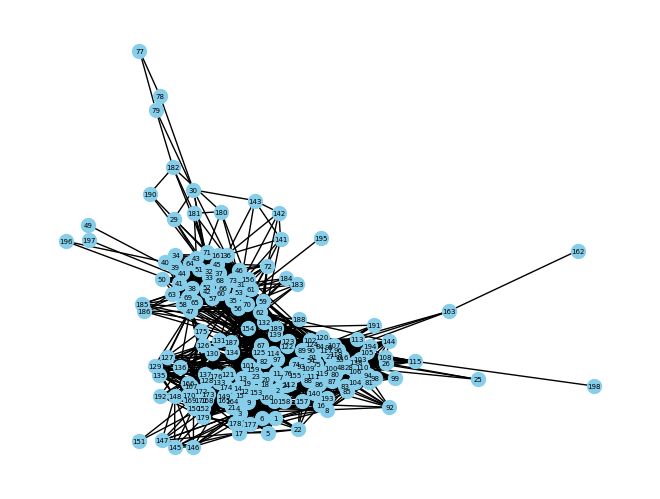

In [7]:
# using networkx to visualize the graph:
G_nx = from_pydot(graph)
pos = nx.spring_layout(G_nx)
nx.draw(G_nx, pos, with_labels=True, node_size=100, node_color="skyblue", font_size=5, font_color="black")
plt.show()

PROBLEM: it doesn't work with data_name_2

Alternatively, we've created some custom functions to draw the graph layout:

- random_0: a baseline version where the nodes are drawn in random positions

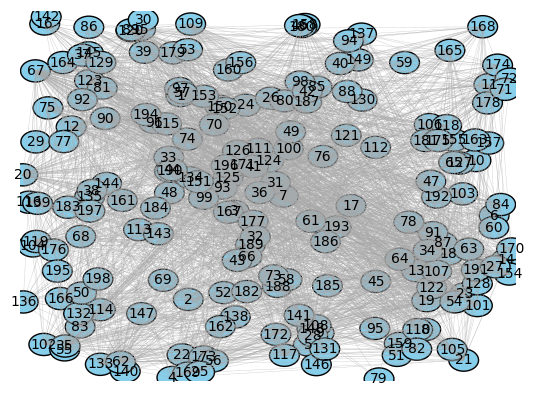

In [8]:
def get_unique_random_position(existing_positions, max_attempts=100):
    """Generate a unique random position that does not overlap significantly with existing ones."""
    for _ in range(max_attempts):
        pos = np.random.rand(2)
        if all(np.linalg.norm(pos - existing) > 0.05 for existing in existing_positions.values()):
            return pos
    return np.random.rand(2)  # Fallback if no unique position is found

# Get the list of nodes and edges
nodes = graph.get_nodes()
edges = graph.get_edges()

# Create a dictionary to store node positions
node_positions = {}

# Initialize the plot
fig, ax = plt.subplots()

# Generate a random position and plot a circle for each node
for node in nodes:
    pos = np.random.rand(2)
    node_positions[node.get_name()] = pos
    ax.add_patch(Circle(pos, radius=0.03, edgecolor='black', facecolor='skyblue'))
    ax.text(pos[0], pos[1], node.get_name(), fontsize=10, ha='center', va='center')

# Draw lines to connect the circles based on edges
for edge in edges:
    source_pos = node_positions[edge.get_source()]
    destination_pos = node_positions[edge.get_destination()]
    ax.add_patch(ConnectionPatch(
        source_pos, destination_pos, 'data', 'data', color='#A9A9A9', # dark grey lines
        linestyle=':', linewidth=0.3  # Make lines thinner and dotted
    ))


# Set plot limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Hide the axes
ax.axis('off')

plt.show()


This visualization looks very confused, we may opt for other solutions:

- random_1: Hari's version;

In [9]:
# change to graph 2
#G = pydot.graph_from_dot_file(data_name_2)
#graph = G[0]

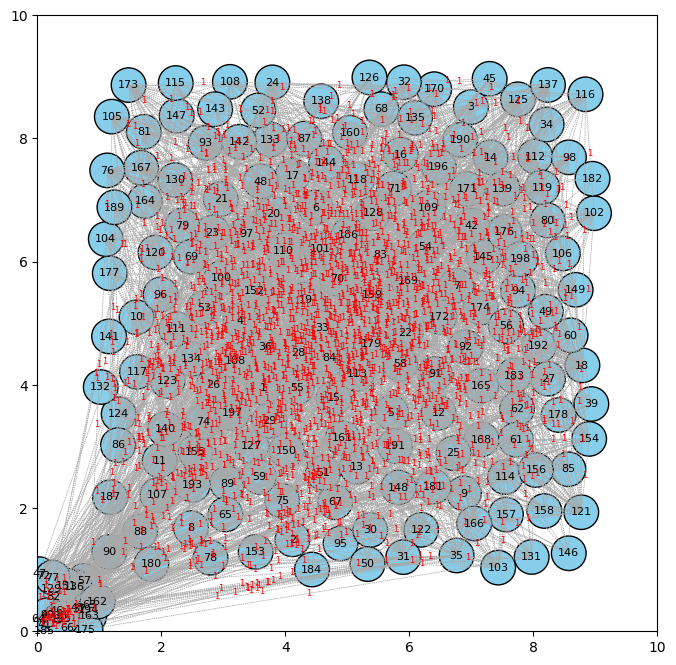

In [10]:
def get_unique_random_position(existing_positions, max_attempts=100):
    """Generate a unique random position that does not overlap significantly with existing ones."""
    for _ in range(max_attempts):
        pos = (0.1 + (0.9 - 0.1) * np.random.rand(2))*10
        if all(np.linalg.norm(pos - existing) > 0.5 for existing in existing_positions.values()):
            return pos
    return np.random.rand(2)  # Fallback if no unique position is found

# Get nodes and edges
nodes = graph.get_nodes()
edges = graph.get_edges()

# Store node positions
node_positions = {}

# Initialize the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Assign unique random positions to nodes
for node in nodes:
    node_name = node.get_name()
    if node_name.isdigit():  # Ensure we ignore special characters
        node_positions[node_name] = get_unique_random_position(node_positions)
        ax.add_patch(Circle(node_positions[node_name], radius=0.28, edgecolor='black', facecolor='skyblue'))
        ax.text(node_positions[node_name][0], node_positions[node_name][1], node_name, fontsize=8, ha='center', va='center')

# Draw edges with weights
for edge in edges:
    source, target = edge.get_source(), edge.get_destination()
    if source.isdigit() and target.isdigit():
        source_pos = node_positions[source]
        target_pos = node_positions[target]
        weight = edge.get_attributes().get("weight", "1")  # Get weight, default to 1
        ax.add_patch(ConnectionPatch(
            source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
        ))
        mid_pos = (source_pos + target_pos) / 2  # Midpoint for weight label
        ax.text(mid_pos[0], mid_pos[1], weight, fontsize=6, color='red', ha='center', va='center')

# Set plot limits
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('on')

plt.show()

PROBLEM: doesn't work well with data_name_1

- circle: ...

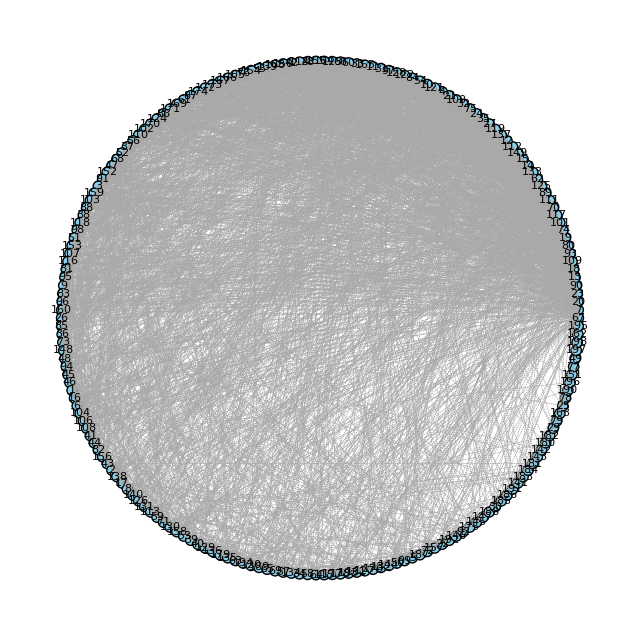

In [11]:
# Convert pydot graph to networkx graph
G_nx = nx.nx_pydot.from_pydot(graph)

# Get nodes and their degrees
node_degrees = dict(G_nx.degree())
sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)

# Calculate positions in a circular layout
num_nodes = len(sorted_nodes)
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
radius = 5

node_positions = {}
for i, node in enumerate(sorted_nodes):
    angle = angles[i]
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    node_positions[node] = (x, y)

# Initialize the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot nodes
for node, pos in node_positions.items():
    ax.add_patch(Circle(pos, radius=0.1, edgecolor='black', facecolor='skyblue'))
    ax.text(pos[0], pos[1], node, fontsize=8, ha='center', va='center')

# Plot edges
for edge in G_nx.edges():
    source_pos = node_positions[edge[0]]
    target_pos = node_positions[edge[1]]
    ax.add_patch(ConnectionPatch(
        source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
    ))
    

# Set plot limits
ax.set_xlim(-radius-1, radius+1)
ax.set_ylim(-radius-1, radius+1)
ax.axis('off')

plt.show()

- nested_circles: nested circles on different # of connections for the nodes (node degree)

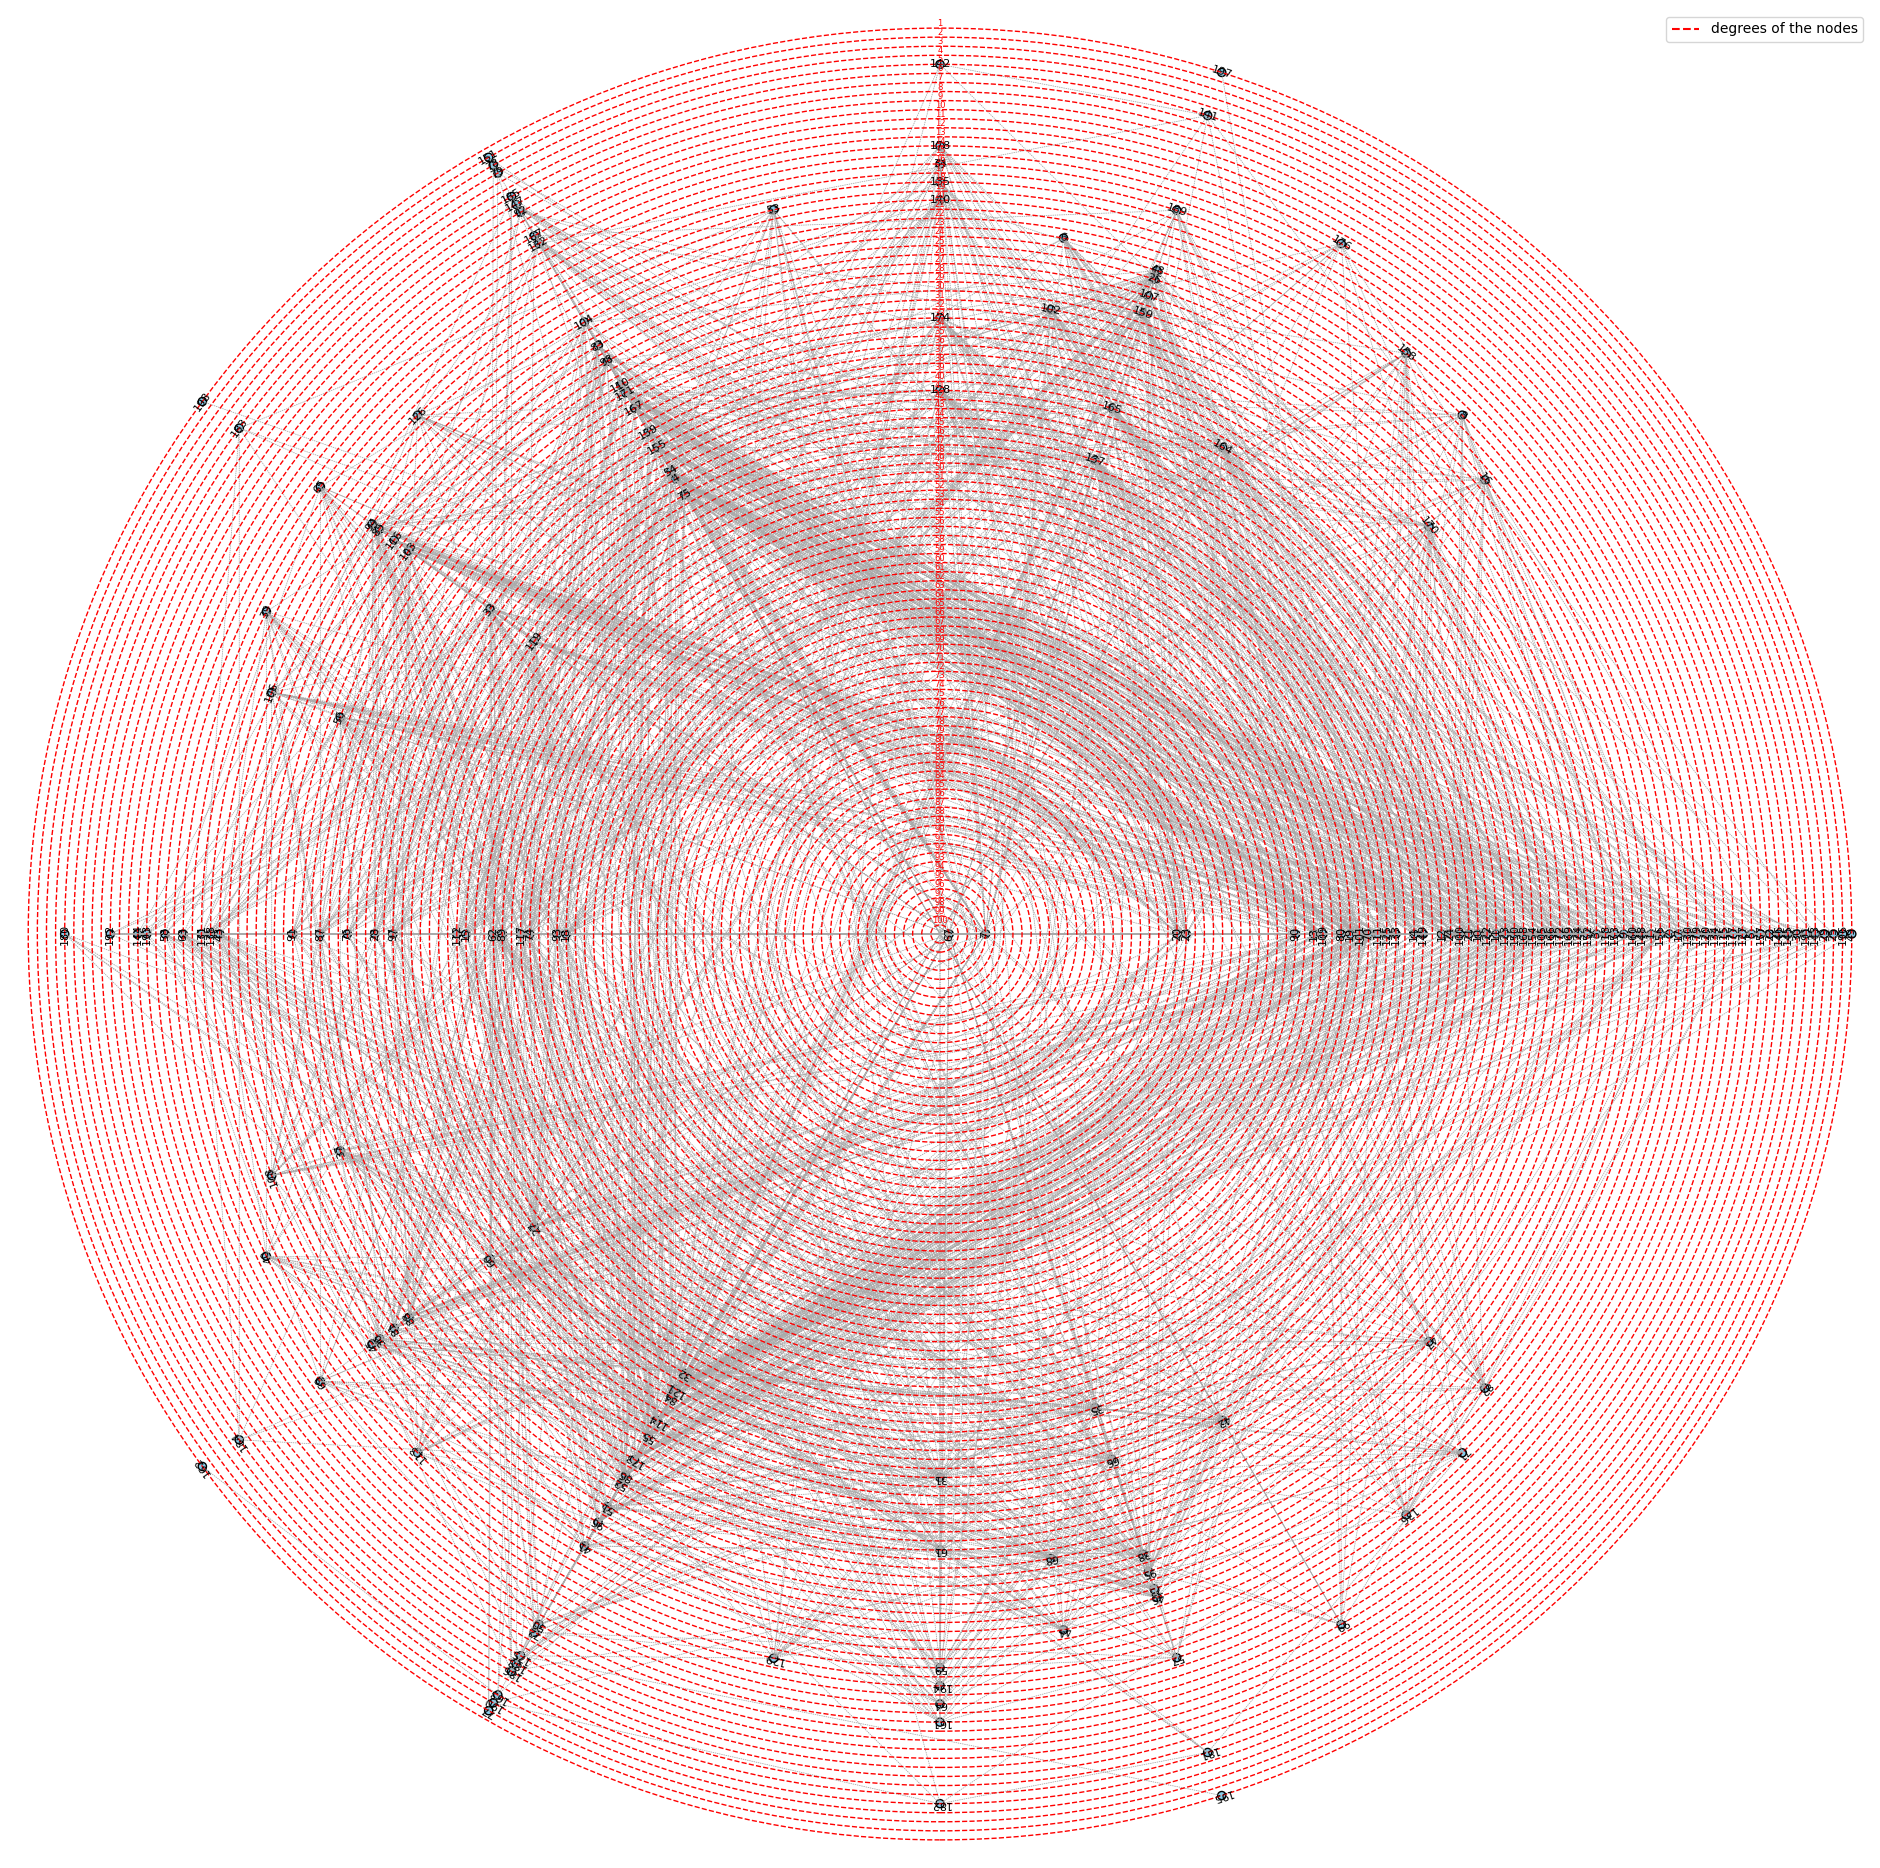

In [112]:
# Convert pydot graph to networkx graph
G_nx = nx.nx_pydot.from_pydot(graph)

# Get nodes and their degrees
node_degrees = dict(G_nx.degree())
sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)

# Get the maximum degree
max_degree = max(node_degrees.values())

# Define radii for different degree levels
radii = {degree: max_degree - degree + 1 for degree in range(1, max_degree + 1)}

# Initialize node positions dictionary
node_positions = {}
node_angles = {}  # To store angles for label rotation

# Assign positions to nodes based on their degrees
for degree in range(max_degree, 0, -1):
    nodes_with_degree = [node for node in sorted_nodes if node_degrees[node] == degree]
    num_nodes = len(nodes_with_degree)
    angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
    radius = radii[degree]

    for i, node in enumerate(nodes_with_degree):
        angle = angles[i]
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        node_positions[node] = (x, y)
        node_angles[node] = angle  # Store angle for label rotation

# Calculate figure size dynamically based on the number of nodes
radius_size = len(sorted_nodes) // 8
fig_size = max(radius_size, radius_size)

# Initialize the plot
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

# Plot nodes
for node, pos in node_positions.items():
    ax.add_patch(Circle(pos, radius=0.45, edgecolor='black', facecolor='skyblue'))

    # Calculate angle in degrees for rotation
    angle_rad = node_angles[node]
    angle_deg = np.degrees(angle_rad)

    # Adjust angle for radial alignment (perpendicular to circumference)
    rotation_angle = angle_deg + 90  # Rotate 90 degrees from tangent to get radial alignment

    # Ensure the text is always upright
    if rotation_angle > 90:
        rotation_angle -= 180
    elif rotation_angle < -90:
        rotation_angle += 180

    # Offset the label position slightly away from the node
    offset_radius = radii[node_degrees[node]]
    x_text = offset_radius * np.cos(angle_rad)
    y_text = offset_radius * np.sin(angle_rad)

    # Adjust text alignment based on position
    ha = 'center'
    va = 'center'

    # Place text with rotation
    ax.text(
        x_text, y_text, str(node), fontsize=8,
        ha=ha, va=va, rotation=rotation_angle,
        rotation_mode='anchor'
    )

# Plot edges
for edge in G_nx.edges():
    source_pos = node_positions[edge[0]]
    target_pos = node_positions[edge[1]]
    ax.add_patch(ConnectionPatch(
        source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
    ))

# Plot red dotted circumferences and add text labels
for degree, radius in radii.items():
    ax.add_patch(Circle((0, 0), radius=radius, edgecolor='red', facecolor='none', linestyle='--'))
    ax.text(0, radius, f'{degree}', color='red', ha='center', va='bottom', fontsize=6)

# Add legend
red_dotted_line = plt.Line2D([0], [0], linestyle='--', color='red', label='degrees of the nodes')
ax.legend(handles=[red_dotted_line], loc='upper right')

# Set plot limits
max_radius = max(radii.values()) + 2
ax.set_xlim(-max_radius, max_radius)
ax.set_ylim(-max_radius, max_radius)
ax.axis('off')

plt.show()


Main problem: font size

Then there are all the metrics....